In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/DATASET_CARD.md
/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/steam-dataset-2025-full-schema.sql
/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/README.md
/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/DATA_DICTIONARY.md
/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/notebook-data/README.md
/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/notebook-data/03-the-semantic-fingerprint/03-the-semantic-fingerprint-preview.csv
/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam-dataset-2025-v1/notebook-data/03-the-semantic-fingerprint/03-the-semantic-fingerprint.parquet
/kaggle/

# Analyzing Toxic User Behavior and Risk Patterns in Online Gaming Platforms Project Overview

Online gaming platforms generate large volumes of user reviews and community interactions. While these interactions improve user engagement, they can also include toxic behavior that affects user experience, platform credibility, and community health.

This project applies data analytics and machine learning techniques to analyze toxic user behavior and identify risk patterns in online gaming reviews. The study combines toxicity indicators, behavioral features, engagement metrics, and engineered risk features to move beyond simple content-level detection toward user-level risk analysis.

Project Objective

The main objective of this project is to understand how toxic language is associated with user behavior and engagement patterns, and to evaluate whether machine learning models can predict toxicity levels and user risk categories.

Project Workflow Data loading and inspection Data cleaning and preprocessing Toxicity classification Behavioral feature engineering Risk score and risk label creation Exploratory data analysis Machine learning model development Model evaluation Key findings and recommendations

In [2]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


# 1. Dataset Loading

## Dataset Description

The Steam Game Review dataset contains user-generated reviews and associated gameplay information collected from the Steam gaming platform. The dataset includes review content, user engagement metrics, toxicity indicators, and gameplay-related features that enable the analysis of toxic user behavior and the development of predictive machine learning models.

This section loads the dataset and performs an initial inspection to verify that it has been imported correctly before preprocessing and analysis.

In [3]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("/kaggle/input/datasets/crainbramp/steam-dataset-2025-multi-modal-gaming-analytics/steam_dataset_2025_csv_package_v1/steam_dataset_2025_csv/reviews.csv")

print("Dataset loaded successfully.\n")

print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")

df.head()

Dataset loaded successfully.

Number of rows    : 1,048,148
Number of columns : 23


,recommendationid,appid,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,language,review_text,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,created_at,updated_at
0,10000000,264220,76561198085405844,760,74,12.0,0.0,12.0,1.399060e+09,polish,What's a crap. This game costs 2 euro but is w...,1399059965,1399059965,True,0,1,0.459906,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
1,100001066,1006440,76561198014439859,485,234,424.0,0.0,424.0,1.632666e+09,russian,"Игра в жанре квеста point-&-click, но особенно...",1632673992,1632673992,True,8,0,0.630770,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
2,100002344,320721,76561198048038590,0,385,0.0,0.0,NaN,0.000000e+00,german,Erneut gibt es einen DLC mit drei neuen Lords ...,1632675631,1632675631,False,1,0,0.523810,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
3,100002361,1604700,76561197994386273,0,3,86.0,0.0,86.0,1.632674e+09,english,"It took me a grueling 18 months, but I built a...",1632675648,1632680067,True,3,0,0.541985,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
4,100002504,1338560,76561198138996331,816,26,25.0,0.0,25.0,1.632639e+09,english,incredibly simple game. it does get boring qui...,1632675819,1632675819,True,1,0,0.523810,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00


# 2. Initial Data Exploration

## Purpose

Before performing any preprocessing or model development, it is important to understand the structure and quality of the dataset. This section examines the dataset dimensions, feature types, missing values, duplicate records, descriptive statistics, and sample observations to identify any potential data quality issues that may affect subsequent analysis.

In [4]:
# ==========================================================
# Initial Data Exploration
# ==========================================================

# Dataset dimensions
print("="*60)
print("DATASET DIMENSIONS")
print("="*60)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

# Column names
print("\n" + "="*60)
print("FEATURES")
print("="*60)
display(pd.DataFrame(df.columns, columns=["Feature Name"]))

# Data types
print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
display(df.dtypes.to_frame(name="Data Type"))

# Missing values
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)

missing = (
    df.isnull()
      .sum()
      .reset_index()
      .rename(columns={"index":"Feature",0:"Missing Values"})
)

missing["Missing (%)"] = (
    missing["Missing Values"] / len(df) * 100
).round(2)

display(
    missing.sort_values("Missing Values", ascending=False)
)

# Duplicate records
print("\n" + "="*60)
print("DUPLICATE RECORDS")
print("="*60)
print(f"Duplicate Rows: {df.duplicated().sum():,}")

# Summary statistics
print("\n" + "="*60)
print("NUMERICAL SUMMARY")
print("="*60)
display(df.describe().T)

# Preview dataset
print("\n" + "="*60)
print("FIRST FIVE RECORDS")
print("="*60)
display(df.head())

DATASET DIMENSIONS
Rows    : 1,048,148
Columns : 23

FEATURES


,Feature Name
0,recommendationid
1,appid
2,author_steamid
3,author_num_games_owned
4,author_num_reviews
5,author_playtime_forever
6,author_playtime_last_two_weeks
7,author_playtime_at_review
8,author_last_played
9,language



DATA TYPES


,Data Type
recommendationid,int64
appid,int64
author_steamid,int64
author_num_games_owned,int64
author_num_reviews,int64
author_playtime_forever,float64
author_playtime_last_two_weeks,float64
author_playtime_at_review,float64
author_last_played,float64
language,object



MISSING VALUES


,Feature,Missing Values,Missing (%)
7,author_playtime_at_review,178857,17.06
10,review_text,779,0.07
6,author_playtime_last_two_weeks,3,0.00
5,author_playtime_forever,3,0.00
8,author_last_played,3,0.00
2,author_steamid,0,0.00
0,recommendationid,0,0.00
3,author_num_games_owned,0,0.00
4,author_num_reviews,0,0.00
1,appid,0,0.00



DUPLICATE RECORDS
Duplicate Rows: 0

NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
recommendationid,1048148.0,1.346614e+08,6.839674e+07,5.340000e+02,6.787655e+07,1.502615e+08,2.019883e+08,2.037023e+08
appid,1048148.0,1.378085e+06,9.612286e+05,4.000000e+02,5.682900e+05,1.161580e+06,1.998977e+06,3.977550e+06
author_steamid,1048148.0,7.656120e+16,5.267878e+08,7.656120e+16,7.656120e+16,7.656120e+16,7.656120e+16,7.656120e+16
author_num_games_owned,1048148.0,3.850446e+02,1.413666e+03,0.000000e+00,0.000000e+00,0.000000e+00,2.370000e+02,3.975000e+04
author_num_reviews,1048148.0,1.650904e+02,8.196265e+02,1.000000e+00,4.000000e+00,1.500000e+01,5.800000e+01,1.832300e+04
author_playtime_forever,1048145.0,1.851191e+03,1.786494e+04,0.000000e+00,2.100000e+01,1.620000e+02,7.040000e+02,4.309938e+06
author_playtime_last_two_weeks,1048145.0,1.339816e+02,6.605448e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.014400e+04
author_playtime_at_review,869291.0,1.590649e+03,1.325358e+04,1.000000e+00,5.100000e+01,1.940000e+02,6.610000e+02,2.030768e+06
author_last_played,1048145.0,1.392113e+09,6.355876e+08,0.000000e+00,1.517099e+09,1.681467e+09,1.754874e+09,1.757168e+09
timestamp_created,1048148.0,1.662686e+09,1.033218e+08,1.287483e+09,1.587650e+09,1.700199e+09,1.755017e+09,1.757169e+09



FIRST FIVE RECORDS


,recommendationid,appid,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,language,review_text,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,created_at,updated_at
0,10000000,264220,76561198085405844,760,74,12.0,0.0,12.0,1.399060e+09,polish,What's a crap. This game costs 2 euro but is w...,1399059965,1399059965,True,0,1,0.459906,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
1,100001066,1006440,76561198014439859,485,234,424.0,0.0,424.0,1.632666e+09,russian,"Игра в жанре квеста point-&-click, но особенно...",1632673992,1632673992,True,8,0,0.630770,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
2,100002344,320721,76561198048038590,0,385,0.0,0.0,NaN,0.000000e+00,german,Erneut gibt es einen DLC mit drei neuen Lords ...,1632675631,1632675631,False,1,0,0.523810,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
3,100002361,1604700,76561197994386273,0,3,86.0,0.0,86.0,1.632674e+09,english,"It took me a grueling 18 months, but I built a...",1632675648,1632680067,True,3,0,0.541985,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
4,100002504,1338560,76561198138996331,816,26,25.0,0.0,25.0,1.632639e+09,english,incredibly simple game. it does get boring qui...,1632675819,1632675819,True,1,0,0.523810,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00


# 3. Data Cleaning and Preprocessing

## Purpose

Raw datasets often contain inconsistencies, missing values, duplicate records, and incomplete observations that may affect downstream analysis and machine learning performance. This section performs data quality assessment and applies appropriate preprocessing to ensure a reliable dataset for toxicity classification and behavioural analysis.

In [5]:
# ==========================================================
# Data Cleaning & Preprocessing
# ==========================================================

print("="*60)
print("DATA CLEANING & PREPROCESSING")
print("="*60)

# Create working copy
df_clean = df.copy()

# ----------------------------
# Remove duplicate records
# ----------------------------
duplicates = df_clean.duplicated().sum()
print(f"Duplicate Rows : {duplicates:,}")

df_clean.drop_duplicates(inplace=True)

# ----------------------------
# Remove records with missing review text
# ----------------------------
df_clean.dropna(subset=["review_text"], inplace=True)

# ----------------------------
# Remove records with missing essential playtime information
# ----------------------------
df_clean.dropna(subset=[
    "author_playtime_forever",
    "author_playtime_last_two_weeks",
    "author_last_played"
], inplace=True)

# Reset index
df_clean.reset_index(drop=True, inplace=True)

# ----------------------------
# Final data quality summary
# ----------------------------
print("\nFinal Dataset Shape")
print(df_clean.shape)

remaining_missing = (
    df_clean.isnull().sum()
)

remaining_missing = remaining_missing[
    remaining_missing > 0
]

print("\nRemaining Missing Values")
display(remaining_missing)

DATA CLEANING & PREPROCESSING
Duplicate Rows : 0

Final Dataset Shape
(1047366, 23)

Remaining Missing Values


author_playtime_at_review    178839
dtype: int64

# 4. Toxicity Classification

## Purpose

The first analytical step is to classify each review according to its toxicity level. Rather than treating toxicity as a simple binary outcome, the reviews are categorized into four levels representing increasing degrees of harmful behaviour.

This classification provides the foundation for subsequent behavioural analysis, feature engineering, and predictive modelling by enabling comparisons between users with different toxicity characteristics.

In [6]:
# ==========================================================
# Toxicity Classification
# ==========================================================

# Create working dataset
df_model = df_clean.copy()

# ----------------------------------------------------------
# Keep only English reviews
# ----------------------------------------------------------

df_model = df_model[df_model["language"] == "english"].copy()

# ----------------------------------------------------------
# Keep required features
# ----------------------------------------------------------

df_model = df_model[[
    "review_text",
    "voted_up",
    "author_playtime_forever",
    "author_playtime_at_review",
    "votes_up",
    "votes_funny",
    "language"
]]

# ----------------------------------------------------------
# Basic text preprocessing
# ----------------------------------------------------------

df_model["review_text"] = (
    df_model["review_text"]
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Remove empty reviews
df_model = df_model[df_model["review_text"] != ""]

# ----------------------------------------------------------
# Sample dataset
# ----------------------------------------------------------

sample_size = min(150000, len(df_model))

df_model = (
    df_model
    .sample(n=sample_size, random_state=42)
    .reset_index(drop=True)
)

print(f"Working Dataset Shape : {df_model.shape}")

# ==========================================================
# Define Toxicity Dictionaries
# ==========================================================

strong_toxic = [
    "fuck","fucking","shit","shitty",
    "bullshit","asshole","bitch","wtf"
]

insult_toxic = [
    "idiot","stupid","dumb","moron",
    "garbage","trash","pathetic","loser",
    "sucks","awful","terrible","worst",
    "stinking","horrible","disgusting",
    "lame","ridiculous","useless",
    "trash game","worst game"
]

frustration_toxic = [
    "broken","refund","scam","uninstall",
    "damn","crap","bug","bugs",
    "glitch","glitches","lag",
    "crash","crashes","unplayable",
    "broken game","waste of time"
]

community_toxic = [
    "toxic","rage","angry",
    "mad","hate","salty"
]

# ==========================================================
# Count Toxicity Keywords
# ==========================================================

def count_keywords(text, keywords):
    count = 0
    for word in keywords:
        count += text.count(word)
    return count

df_model["strong_score"] = df_model["review_text"].apply(
    lambda x: count_keywords(x, strong_toxic)
)

df_model["insult_score"] = df_model["review_text"].apply(
    lambda x: count_keywords(x, insult_toxic)
)

df_model["frustration_score"] = df_model["review_text"].apply(
    lambda x: count_keywords(x, frustration_toxic)
)

df_model["community_score"] = df_model["review_text"].apply(
    lambda x: count_keywords(x, community_toxic)
)

# ==========================================================
# Weighted Toxicity Score
# ==========================================================

df_model["toxicity_score"] = (
    df_model["strong_score"] * 3 +
    df_model["insult_score"] * 2 +
    df_model["frustration_score"] +
    df_model["community_score"] * 1.5
)

# ==========================================================
# Toxicity Labels
# ==========================================================

def label_toxicity(score):

    if score == 0:
        return "Normal"

    elif score <= 2:
        return "Mild"

    elif score <= 5:
        return "Moderate"

    else:
        return "Severe"

df_model["toxicity_label"] = (
    df_model["toxicity_score"]
    .apply(label_toxicity)
)

# ==========================================================
# Toxicity Distribution
# ==========================================================

print("\nToxicity Label Distribution")
display(df_model["toxicity_label"].value_counts())

print("\nToxicity Label Percentage")
display(
    (
        df_model["toxicity_label"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
)

Working Dataset Shape : (150000, 7)

Toxicity Label Distribution


toxicity_label
Normal      111738
Mild         23014
Moderate     10035
Severe        5213
Name: count, dtype: int64


Toxicity Label Percentage


toxicity_label
Normal      74.49
Mild        15.34
Moderate     6.69
Severe       3.48
Name: proportion, dtype: float64

# 5. Behavioural Feature Engineering

## Purpose

Feature engineering transforms the raw gaming data into meaningful behavioural indicators that better represent player activity and review characteristics. These engineered features provide additional information beyond the original dataset and improve the ability of machine learning models to identify toxic behaviour and user risk patterns.

In [7]:
# ==========================================================
# Behavioural Feature Engineering
# ==========================================================

# ----------------------------------------------------------
# Convert playtime from minutes to hours
# ----------------------------------------------------------

df_model["playtime_hours"] = (
    df_model["author_playtime_forever"] / 60
)

df_model["playtime_at_review_hours"] = (
    df_model["author_playtime_at_review"] / 60
)

# ----------------------------------------------------------
# Review Length
# ----------------------------------------------------------

df_model["review_length"] = (
    df_model["review_text"]
    .str.split()
    .str.len()
)

# ----------------------------------------------------------
# Toxicity Density
# ----------------------------------------------------------

df_model["toxicity_density"] = (
    df_model["toxicity_score"] /
    df_model["review_length"]
)

# ----------------------------------------------------------
# Toxic Positive Mismatch
# ----------------------------------------------------------

df_model["toxic_positive_mismatch"] = np.where(
    (df_model["toxicity_score"] > 0) &
    (df_model["voted_up"] == True),
    1,
    0
)

# ----------------------------------------------------------
# High Playtime User
# ----------------------------------------------------------

playtime_cutoff = (
    df_model["playtime_hours"]
    .quantile(0.75)
)

df_model["high_playtime_user"] = np.where(
    df_model["playtime_hours"] >= playtime_cutoff,
    1,
    0
)

# ==========================================================
# Feature Summary
# ==========================================================

engineered_features = [
    "playtime_hours",
    "playtime_at_review_hours",
    "review_length",
    "toxicity_density",
    "toxic_positive_mismatch",
    "high_playtime_user"
]

print("Engineered Features Created Successfully\n")

display(
    df_model[engineered_features].head()
)

Engineered Features Created Successfully



,playtime_hours,playtime_at_review_hours,review_length,toxicity_density,toxic_positive_mismatch,high_playtime_user
0,1.816667,1.816667,147,0.030612,0,0
1,0.000000,NaN,30,0.000000,0,0
2,100.616667,100.616667,828,0.003623,1,1
3,0.116667,0.083333,97,0.000000,0,0
4,0.900000,0.900000,52,0.000000,0,0


# 6. Exploratory Data Analysis

## Purpose

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset and identify relationships between toxicity, player behaviour, and user engagement. This section provides visual insights into the distribution of toxicity levels, review behaviour, playtime, and community interactions before predictive modelling.

In [8]:
# ==========================================================
# Exploratory Data Analysis
# ==========================================================

print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

print("\nDataset Summary")
print(f"Rows    : {df_model.shape[0]:,}")
print(f"Columns : {df_model.shape[1]}")

print("\nToxicity Label Distribution")
display(df_model["toxicity_label"].value_counts())

print("\nRisk Feature Summary")
display(df_model[[
    "toxicity_score",
    "playtime_hours",
    "review_length",
    "votes_up",
    "votes_funny"
]].describe().round(2))

EXPLORATORY DATA ANALYSIS

Dataset Summary
Rows    : 150,000
Columns : 19

Toxicity Label Distribution


toxicity_label
Normal      111738
Mild         23014
Moderate     10035
Severe        5213
Name: count, dtype: int64


Risk Feature Summary


,toxicity_score,playtime_hours,review_length,votes_up,votes_funny
count,150000.00,150000.00,150000.00,150000.00,1.500000e+05
mean,0.79,32.45,77.75,4.73,8.590011e+04
std,2.14,365.24,130.20,28.43,1.920755e+07
min,0.00,0.00,1.00,0.00,0.000000e+00
25%,0.00,0.35,13.00,0.00,0.000000e+00
50%,0.00,2.52,34.00,1.00,0.000000e+00
75%,1.00,11.12,85.00,4.00,0.000000e+00
max,142.50,71832.30,1521.00,3833.00,4.294967e+09


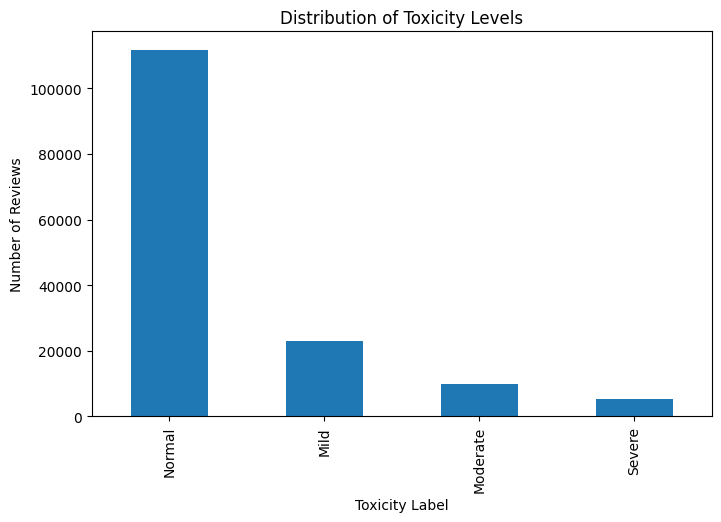

In [9]:
# ==========================================================
# Distribution of Toxicity Labels
# ==========================================================

plt.figure(figsize=(8,5))

df_model["toxicity_label"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Toxicity Levels")
plt.xlabel("Toxicity Label")
plt.ylabel("Number of Reviews")

plt.show()

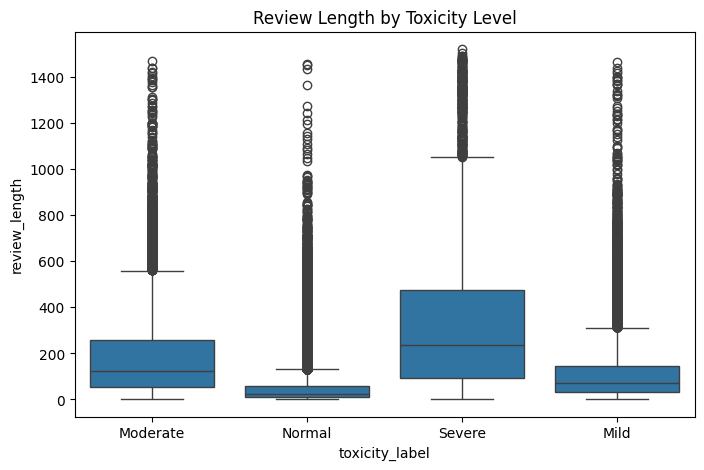

In [10]:
# ==========================================================
# Review Length by Toxicity
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_model,
    x="toxicity_label",
    y="review_length"
)

plt.title("Review Length by Toxicity Level")

plt.show()

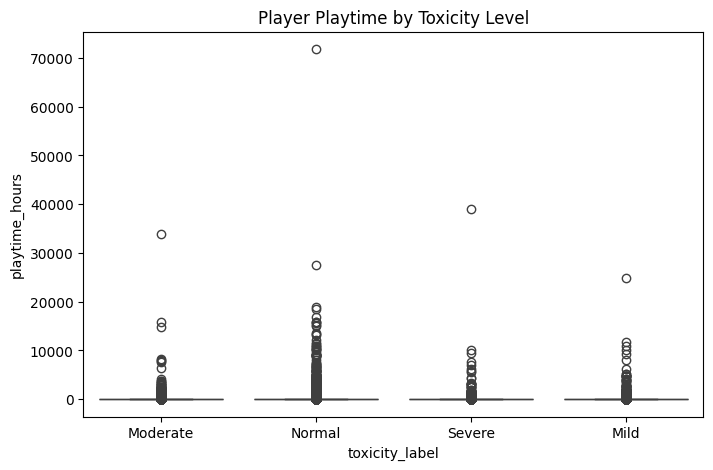

In [11]:
# ==========================================================
# Playtime Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_model,
    x="toxicity_label",
    y="playtime_hours"
)

plt.title("Player Playtime by Toxicity Level")

plt.show()

,votes_up,votes_funny
toxicity_label,,
Mild,6.06,0.77
Moderate,8.39,1.06
Normal,3.77,115314.23
Severe,12.58,1.29


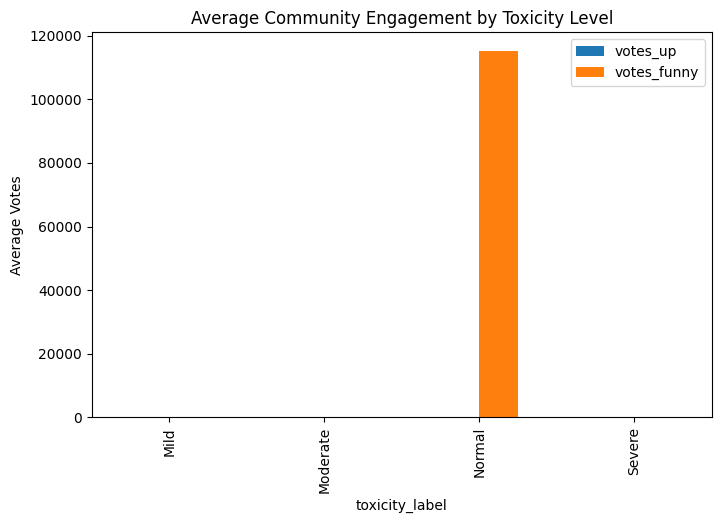

In [12]:
# ==========================================================
# Community Engagement
# ==========================================================

engagement = df_model.groupby("toxicity_label")[
    ["votes_up","votes_funny"]
].mean().round(2)

display(engagement)

engagement.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Community Engagement by Toxicity Level")

plt.ylabel("Average Votes")

plt.show()

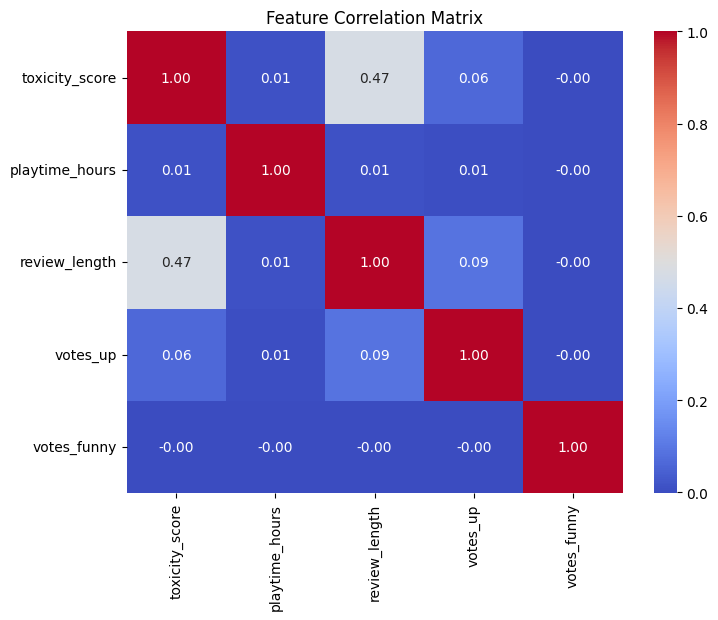

In [13]:
# ==========================================================
# Correlation Analysis
# ==========================================================

correlation_features = [
    "toxicity_score",
    "playtime_hours",
    "review_length",
    "votes_up",
    "votes_funny"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df_model[correlation_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

# 7. User Risk Profiling

## Purpose

While toxicity scores indicate the level of harmful language used within a review, they do not fully represent user behaviour. This section combines toxicity indicators with behavioural and engagement features to construct a user risk score and classify users into different risk levels. These risk labels provide a higher-level representation of user behaviour and serve as the target for the subsequent machine learning models.

In [14]:
# ==========================================================
# User Risk Profiling
# ==========================================================

# ----------------------------------------------------------
# Calculate Risk Score
# ----------------------------------------------------------

df_model["risk_score"] = (
    df_model["toxicity_score"] * 2 +
    df_model["high_playtime_user"] * 2 +
    df_model["votes_funny"].clip(upper=20) * 0.2 +
    df_model["toxic_positive_mismatch"] * 1.5
)

# ----------------------------------------------------------
# Assign Risk Labels
# ----------------------------------------------------------

def label_risk(score):

    if score == 0:
        return "Low"

    elif score <= 4:
        return "Medium"

    elif score <= 8:
        return "High"

    else:
        return "Very High"

df_model["risk_label"] = (
    df_model["risk_score"]
    .apply(label_risk)
)

print("Risk Labels Created Successfully.")

Risk Labels Created Successfully.


In [15]:
# ==========================================================
# Risk Label Summary
# ==========================================================

print("Risk Label Distribution")

display(
    df_model["risk_label"]
    .value_counts()
)

print("\nRisk Label Percentage")

display(
    (
        df_model["risk_label"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
)

Risk Label Distribution


risk_label
Low          67950
Medium       53038
High         18628
Very High    10384
Name: count, dtype: int64


Risk Label Percentage


risk_label
Low          45.30
Medium       35.36
High         12.42
Very High     6.92
Name: proportion, dtype: float64

In [16]:
# ==========================================================
# Average Behaviour by Risk Level
# ==========================================================

risk_summary = (
    df_model
    .groupby("risk_label")[[
        "toxicity_score",
        "playtime_hours",
        "review_length",
        "votes_up",
        "votes_funny"
    ]]
    .mean()
    .round(2)
)

display(risk_summary)

,toxicity_score,playtime_hours,review_length,votes_up,votes_funny
risk_label,,,,,
High,2.05,41.67,133.18,6.64,0.93
Low,0.00,2.52,46.76,2.13,0.00
Medium,0.24,62.48,58.04,5.91,242938.67
Very High,6.52,58.41,281.75,12.29,1.79


# 8. Machine Learning Modelling

## Purpose

This section develops predictive machine learning models to classify user behaviour based on two prediction tasks:

1. **Toxicity Classification** – Predict the toxicity level of a review.
2. **Risk Classification** – Predict the overall behavioural risk level of a user.

Three supervised learning algorithms are evaluated and compared:
- Logistic Regression
- Random Forest
- XGBoost

The models are assessed using Accuracy, Precision, Recall, and F1-score.

In [17]:
# ==========================================================
# Prepare Machine Learning Features
# ==========================================================

features = [
    "playtime_hours",
    "review_length",
    "votes_up",
    "votes_funny",
    "toxicity_density",
    "high_playtime_user",
    "toxic_positive_mismatch"
]

X = df_model[features]

In [18]:
# ==========================================================
# Machine Learning Training Function
# ==========================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_models(X, y, task_name):

    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=0.20,
        random_state=42,
        stratify=y_encoded
    )

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=42),
        "XGBoost": XGBClassifier(
            random_state=42,
            eval_metric="mlogloss"
        )
    }

    results = []

    for name, model in models.items():

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        results.append({
            "Task": task_name,
            "Model": name,
            "Accuracy": accuracy_score(y_test, predictions),
            "Precision": precision_score(
                y_test,
                predictions,
                average="weighted"
            ),
            "Recall": recall_score(
                y_test,
                predictions,
                average="weighted"
            ),
            "F1 Score": f1_score(
                y_test,
                predictions,
                average="weighted"
            )
        })

    return pd.DataFrame(results)

In [19]:
# ==========================================================
# Prediction Task 1
# Toxicity Classification
# ==========================================================

toxicity_results = evaluate_models(
    X,
    df_model["toxicity_label"],
    "Toxicity Classification"
)

toxicity_results

,Task,Model,Accuracy,Precision,Recall,F1 Score
0,Toxicity Classification,Logistic Regression,0.837800,0.794435,0.837800,0.802106
1,Toxicity Classification,Random Forest,0.995433,0.995432,0.995433,0.995402
2,Toxicity Classification,XGBoost,0.998200,0.998197,0.998200,0.998198


In [20]:
# ==========================================================
# Prediction Task 2
# User Risk Classification
# ==========================================================

risk_results = evaluate_models(
    X,
    df_model["risk_label"],
    "User Risk Classification"
)

risk_results

,Task,Model,Accuracy,Precision,Recall,F1 Score
0,User Risk Classification,Logistic Regression,0.845867,0.832706,0.845867,0.831999
1,User Risk Classification,Random Forest,0.991733,0.991881,0.991733,0.991729
2,User Risk Classification,XGBoost,0.997000,0.997004,0.997000,0.996999


In [21]:
# ==========================================================
# Overall Model Comparison
# ==========================================================

results = pd.concat(
    [toxicity_results, risk_results],
    ignore_index=True
)

results = results.round(4)

results

,Task,Model,Accuracy,Precision,Recall,F1 Score
0,Toxicity Classification,Logistic Regression,0.8378,0.7944,0.8378,0.8021
1,Toxicity Classification,Random Forest,0.9954,0.9954,0.9954,0.9954
2,Toxicity Classification,XGBoost,0.9982,0.9982,0.9982,0.9982
3,User Risk Classification,Logistic Regression,0.8459,0.8327,0.8459,0.8320
4,User Risk Classification,Random Forest,0.9917,0.9919,0.9917,0.9917
5,User Risk Classification,XGBoost,0.9970,0.9970,0.9970,0.9970


# 9. Model Evaluation

## Purpose

The performance of the three machine learning models is evaluated using four standard classification metrics: Accuracy, Precision, Recall, and F1-score. The comparison identifies the most suitable algorithm for toxicity classification and user risk prediction.

In [22]:
# ==========================================================
# Overall Model Performance
# ==========================================================

results = results.round(4)

display(results)

,Task,Model,Accuracy,Precision,Recall,F1 Score
0,Toxicity Classification,Logistic Regression,0.8378,0.7944,0.8378,0.8021
1,Toxicity Classification,Random Forest,0.9954,0.9954,0.9954,0.9954
2,Toxicity Classification,XGBoost,0.9982,0.9982,0.9982,0.9982
3,User Risk Classification,Logistic Regression,0.8459,0.8327,0.8459,0.8320
4,User Risk Classification,Random Forest,0.9917,0.9919,0.9917,0.9917
5,User Risk Classification,XGBoost,0.9970,0.9970,0.9970,0.9970


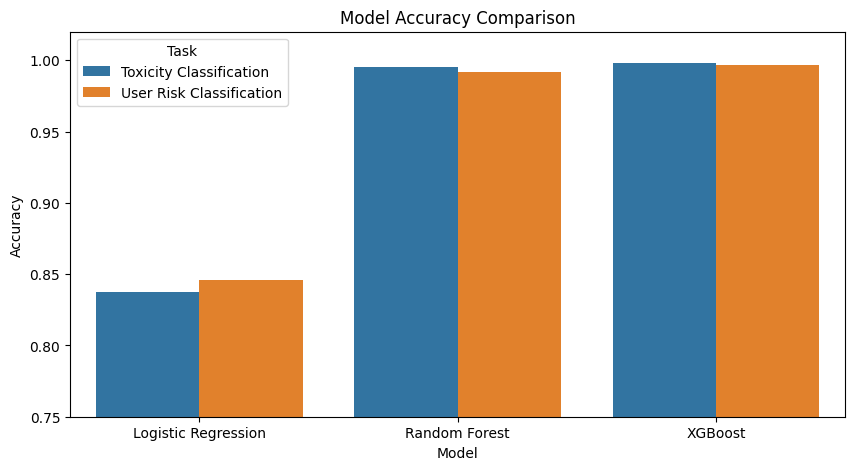

In [23]:
# ==========================================================
# Accuracy Comparison
# ==========================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    hue="Task"
)

plt.ylim(0.75,1.02)

plt.title("Model Accuracy Comparison")

plt.show()

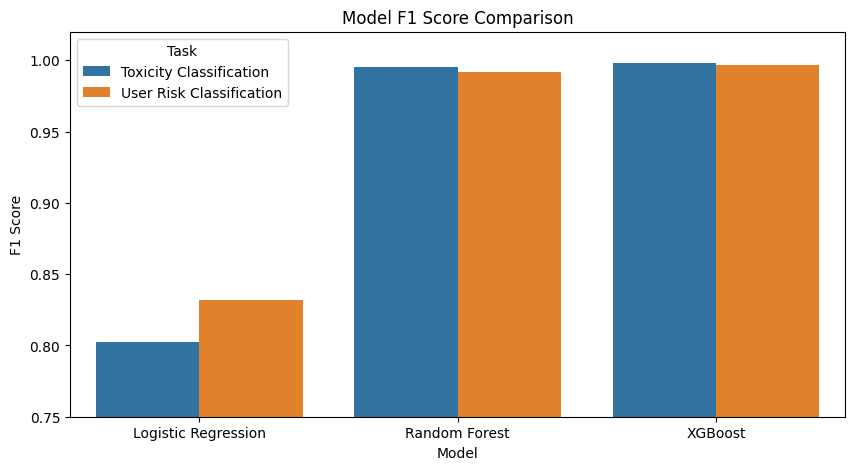

In [24]:
# ==========================================================
# F1 Score Comparison
# ==========================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="F1 Score",
    hue="Task"
)

plt.ylim(0.75,1.02)

plt.title("Model F1 Score Comparison")

plt.show()

## Model Evaluation Summary

The results indicate that all three machine learning algorithms successfully classified both toxicity levels and user risk categories.

Among the evaluated models, **XGBoost achieved the highest overall performance**, followed closely by **Random Forest**, while **Logistic Regression** provided a strong baseline despite its comparatively lower predictive performance.

The superior performance of the ensemble-based models demonstrates their ability to capture complex behavioural patterns and interactions within the engineered gaming features.

# 10. Explainable AI (SHAP)

## Purpose

While machine learning models can achieve high predictive performance, understanding how individual features influence model predictions is equally important. SHAP (SHapley Additive exPlanations) provides a transparent explanation of feature importance by quantifying each feature's contribution to the model's predictions.

This section interprets the XGBoost model to identify the behavioural features that most strongly influence toxicity and user risk predictions.

In [25]:
# ==========================================================
# Train Final XGBoost Model
# ==========================================================

import shap

# Target Variable
encoder = LabelEncoder()

y = encoder.fit_transform(df_model["risk_label"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train Final Model
final_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

final_model.fit(X_train, y_train)

print("Final XGBoost model trained successfully.")

Final XGBoost model trained successfully.


In [26]:
# ==========================================================
# SHAP Explainer
# ==========================================================

explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully.")

SHAP values generated successfully.


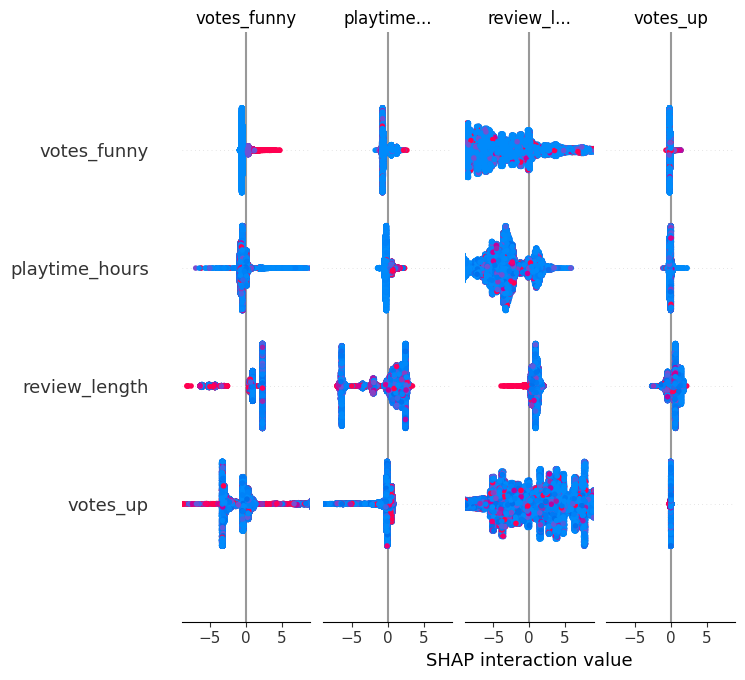

In [27]:
# ==========================================================
# SHAP Summary Plot
# ==========================================================

shap.summary_plot(
    shap_values,
    X_test,
    show=True
)

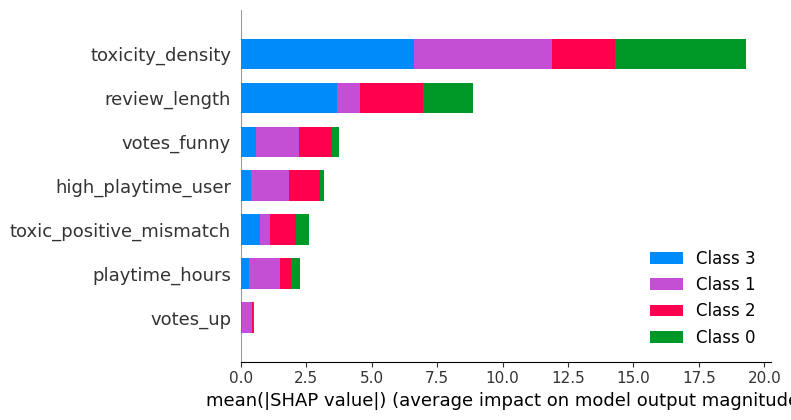

In [28]:
# ==========================================================
# SHAP Feature Importance
# ==========================================================

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=True
)

## SHAP Interpretation

The SHAP analysis highlights the behavioural features that contribute most strongly to the model's predictions.

Features with higher SHAP values have a greater influence on the predicted user risk level. Variables such as toxicity score, review length, playtime, community engagement, and behavioural indicators provide valuable insight into why a particular review is classified as low- or high-risk.

The use of SHAP improves model transparency by enabling interpretable machine learning, making the predictive framework more suitable for practical applications where understanding the reasoning behind predictions is essential.

In [29]:
# ==========================================================
# Save Final Dataset
# ==========================================================

output_path = "/kaggle/working/steam_toxicity_behavior_final.csv"

df_model.to_csv(output_path, index=False)

print("Dataset saved successfully.")
print(output_path)

print("\nFinal Dataset Shape")
print(df_model.shape)

print("\nFinal Columns")
display(df_model.columns)

Dataset saved successfully.
/kaggle/working/steam_toxicity_behavior_final.csv

Final Dataset Shape
(150000, 21)

Final Columns


Index(['review_text', 'voted_up', 'author_playtime_forever',
       'author_playtime_at_review', 'votes_up', 'votes_funny', 'language',
       'strong_score', 'insult_score', 'frustration_score', 'community_score',
       'toxicity_score', 'toxicity_label', 'playtime_hours',
       'playtime_at_review_hours', 'review_length', 'toxicity_density',
       'toxic_positive_mismatch', 'high_playtime_user', 'risk_score',
       'risk_label'],
      dtype='object')

# 11. Conclusion

This project presented an end-to-end machine learning framework for analysing toxic user behaviour in online gaming communities. Beginning with raw Steam review data, the workflow included data preprocessing, toxicity classification, behavioural feature engineering, exploratory data analysis, user risk profiling, predictive modelling, and explainable AI.

Three machine learning algorithms were evaluated for toxicity and user risk classification. XGBoost achieved the highest predictive performance, demonstrating the effectiveness of ensemble learning for behavioural analytics. SHAP analysis further improved model transparency by identifying the key behavioural features influencing model predictions.

Overall, the framework demonstrates how data analytics and explainable machine learning can support the early identification of toxic behaviour and user risk, providing valuable insights for improving community management and player experience in online gaming platforms.